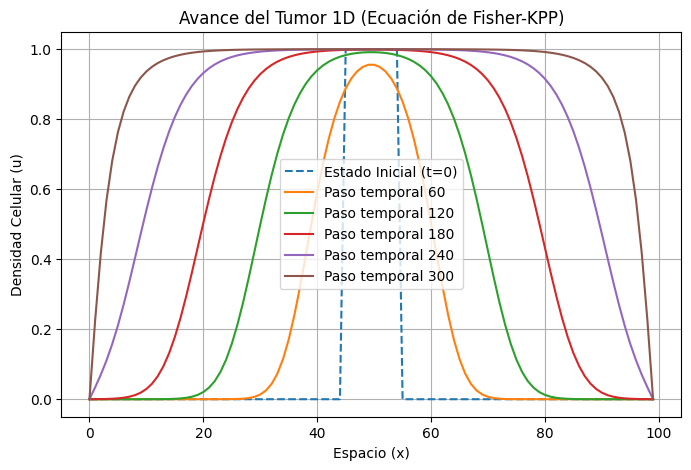

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros físicos (puedes jugar con estos)
D = 1.0      # Coeficiente de difusión
rho = 1.0    # Tasa de proliferación celular

# 2. Parámetros numéricos de la grilla 1D
nx = 100     # Número de puntos en el espacio
dx = 0.5     # Tamaño de cada "celda" espacial
dt = 0.05    # Tamaño del paso temporal 
nt = 300     # Número total de iteraciones temporales

# 3. Inicialización del tejido y el tumor
u = np.zeros(nx)       # Tejido sano (densidad 0)
u[45:55] = 1.0         # Insertamos el tumor inicial en el centro (densidad 1)

# Configuramos el gráfico
plt.figure(figsize=(8, 5))
plt.plot(u, label='Estado Inicial (t=0)', linestyle='--')

# 4. El motor de la simulación (Diferencias Finitas)
for n in range(nt):
    un = u.copy() # Congelamos el estado presente para calcular el futuro
    
    # Aplicamos la fórmula matemática a todos los puntos interiores (vectorizado)
    # u[1:-1] significa "desde el segundo elemento hasta el penúltimo"
    difusion = D * (un[2:] - 2*un[1:-1] + un[:-2]) / dx**2
    reaccion = rho * un[1:-1] * (1 - un[1:-1])
    
    u[1:-1] = un[1:-1] + dt * (difusion + reaccion)
    
    # Guardamos "fotos" de la evolución para graficar
    if (n+1) % 60 == 0:
        plt.plot(u, label=f'Paso temporal {n+1}')

# Detalles visuales
plt.title('Avance del Tumor 1D (Ecuación de Fisher-KPP)')
plt.xlabel('Espacio (x)')
plt.ylabel('Densidad Celular (u)')
plt.legend()
plt.grid(True)
plt.show()